# Data mapped to JSON, then converted to parquet

In [14]:
import sys
from pathlib import Path
import os

# This will change the current working directory to the project directory.
sys.path.append(str(Path((os.getenv("PROJECTS_DIR"))).resolve() / "BioLLMComposition"))
from src.config import PROJECT_DIR, DATA_DIR




In [13]:
import json
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import math
from collections import Counter, defaultdict


def normalize_mongo_extended(value):
    """
    Recursively normalize MongoDB extended JSON into plain Python
    types so pyarrow can infer a clean schema.

    Handles things like:
      {"$oid": "..."}          -> "..."" (str)
      {"$numberInt": "1"}      -> 1     (int)
      {"$numberDouble": "1.5"} -> 1.5   (float)
    and recurses into lists/dicts.
    """
    if isinstance(value, dict):
        # Handle Mongo extended types
        if "$oid" in value:
            return value["$oid"]
        if "$numberInt" in value:
            return int(value["$numberInt"])
        if "$numberDouble" in value:
            s = value["$numberDouble"]
            if s in ("NaN", "nan"):
                return math.nan
            if s in ("Infinity", "inf"):
                return math.inf
            if s in ("-Infinity", "-inf"):
                return -math.inf
            return float(s)
        if "$date" in value:
            # You can choose to keep as string or parse to datetime later
            return value["$date"]

        # Generic dict: recurse on values
        return {k: normalize_mongo_extended(v) for k, v in value.items()}

    elif isinstance(value, list):
        return [normalize_mongo_extended(v) for v in value]

    else:
        # primitive: int/float/str/None/etc
        return value


In [ ]:
data_path = '/home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/dna-protein.json'
out_path = '/home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/dna_protein.parquet'

records = []
with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        raw = json.loads(line)
        norm = normalize_mongo_extended(raw)
        records.append(norm)

print("JSON loaded and normalized!")

# Optional: still make a DataFrame for inspection
df = pd.DataFrame(records)
print("DataFrame created!")
print(df.head())



# Let pyarrow infer nested schema (dna, interfaces, meta_data, protein, etc. stay as nested structs)
table = pa.Table.from_pylist(records)
pq.write_table(table, out_path, compression="zstd")

JSON loaded and normalized!
DataFrame created!
                        _id structure_id  \
0  66f4737c7438fd84e774acac         8wh4   
1  665cf17f3ec3206838e68b37         3bq2   
2  665cf17f3ec3206838e68b44         3exj   
3  665cf1813ec3206838e68b52         5zd4   
4  665cf1813ec3206838e68b5f         1ng9   

                                                 dna  \
0  {'chains': [{'au_chain_id': 'T', 'id': 'T', 'n...   
1  {'chains': [{'au_chain_id': 'P', 'id': 'P', 'n...   
2  {'chains': [{'au_chain_id': 'C', 'id': 'C', 'n...   
3  {'chains': [{'au_chain_id': 'G', 'id': 'G', 'n...   
4  {'chains': [{'au_chain_id': 'E', 'id': 'E', 'n...   

                                          interfaces  \
0  {'models': [[{'dna_entity_id': 'T1', 'interfac...   
1  {'models': [[{'binding_site1': 'GAAGCCGGCGG', ...   
2  {'models': [[{'binding_site1': 'TGAGCATGCTCGAG...   
3  {'models': [[{'binding_site1': 'TTCACACGTGTGAA...   
4  {'models': [[{'binding_site1': 'AGCTGCCAGGCACC...   

              

ArrowInvalid: cannot mix struct and non-struct, non-null values

In [4]:
# Find all keys present
all_keys = set().union(*(r.keys() for r in records))
print(all_keys)

for key in all_keys:
    values = [r.get(key) for r in records]
    try:
        pa.array(values)
        print(f"OK   : {key}")
    except pa.ArrowInvalid as e:
        print(f"FAIL : {key} -> {e}")

{'interfaces', 'protein', 'search', 'meta_data', 'structure_id', 'protein_metadata', '_id', 'dna', 'num_models'}
FAIL : interfaces -> Could not convert '5' with type str: tried to convert to int64
OK   : protein
FAIL : search -> cannot mix list and non-list, non-null values
FAIL : meta_data -> Could not convert '?' with type str: tried to convert to int64
OK   : structure_id
OK   : protein_metadata
OK   : _id
FAIL : dna -> cannot mix struct and non-struct, non-null values
OK   : num_models


In [ ]:
# ---------- 2. Strict nested schema inference ----------

# We only strictly clean these nested columns
NESTED_COLS = ["dna", "interfaces", "meta_data", "search"]

TYPE_DICT = "dict"
TYPE_LIST = "list"
TYPE_INT = "int"
TYPE_FLOAT = "float"
TYPE_STR = "str"
TYPE_BOOL = "bool"
TYPE_NULL = "null"
TYPE_OTHER = "other"


def classify_type(v):
    if v is None:
        return TYPE_NULL
    if isinstance(v, bool):
        return TYPE_BOOL
    if isinstance(v, dict):
        return TYPE_DICT
    if isinstance(v, list):
        return TYPE_LIST
    if isinstance(v, int):
        return TYPE_INT
    if isinstance(v, float):
        return TYPE_FLOAT
    if isinstance(v, str):
        return TYPE_STR
    return TYPE_OTHER


def gather_type_stats(value, path, stats):
    t = classify_type(value)
    stats[path][t] += 1

    if t == TYPE_DICT:
        for k, v in value.items():
            gather_type_stats(v, path + (k,), stats)
    elif t == TYPE_LIST:
        for elem in value:
            gather_type_stats(elem, path + ("<elem>",), stats)


def choose_canonical_type(counter: Counter):
    # Ignore null-only paths
    non_null = {t: c for t, c in counter.items() if t != TYPE_NULL}
    if not non_null:
        return None

    # Prefer structured types first
    if non_null.get(TYPE_DICT, 0) > 0 and len(non_null) == 1:
        return TYPE_DICT
    if non_null.get(TYPE_LIST, 0) > 0 and len(non_null) == 1:
        return TYPE_LIST

    # Numeric preference
    if non_null.get(TYPE_FLOAT, 0) or (
        non_null.get(TYPE_INT, 0) and len(non_null) == 1
    ):
        # if any float or mix of int/float -> float
        return TYPE_FLOAT if non_null.get(TYPE_FLOAT, 0) else TYPE_INT

    if non_null.get(TYPE_INT, 0) and len(non_null) == 1:
        return TYPE_INT

    # Fallbacks: string, bool, other
    if non_null.get(TYPE_STR, 0):
        return TYPE_STR
    if non_null.get(TYPE_BOOL, 0):
        return TYPE_BOOL

    # If truly mixed weird stuff, pick the majority
    return max(non_null.items(), key=lambda kv: kv[1])[0]


def infer_canonical_types_for_column(records, col):
    stats = defaultdict(Counter)
    for r in records:
        v = r.get(col)
        if v is not None:
            gather_type_stats(v, (col,), stats)
    canonical = {}
    for path, counter in stats.items():
        ct = choose_canonical_type(counter)
        if ct is not None:
            canonical[path] = ct
    return canonical


# ---------- 3. Cleaning based on inferred schema ----------

def try_parse_int(s):
    s = s.strip()
    if s.isdigit() or (s.startswith("-") and s[1:].isdigit()):
        return int(s)
    return None


def try_parse_float(s):
    s = s.strip()
    if s in {"NaN", "nan"}:
        return math.nan
    if s in {"Infinity", "inf"}:
        return math.inf
    if s in {"-Infinity", "-inf"}:
        return -math.inf
    try:
        return float(s)
    except ValueError:
        return None


def clean_nested(value, path, canonical_types, errors, row_idx):
    """
    Recursively coerce value to match canonical_types[path],
    collect all mismatches in errors[path].
    """
    ct = canonical_types.get(path)

    # If we don't have a canonical type for this path, still recurse so children are cleaned.
    if ct is None:
        t = classify_type(value)
        if t == TYPE_DICT:
            return {
                k: clean_nested(v, path + (k,), canonical_types, errors, row_idx)
                for k, v in value.items()
            }
        if t == TYPE_LIST:
            return [
                clean_nested(elem, path + ("<elem>",), canonical_types, errors, row_idx)
                for elem in value
            ]
        return value

    # Null is always allowed
    if value is None:
        return None

    t = classify_type(value)

    # ---- Dicts ----
    if ct == TYPE_DICT:
        if t != TYPE_DICT:
            errors[path].append(
                {"row": row_idx, "expected": ct, "actual": t, "value": value}
            )
            return None
        # Clean children
        return {
            k: clean_nested(v, path + (k,), canonical_types, errors, row_idx)
            for k, v in value.items()
        }

    # ---- Lists ----
    if ct == TYPE_LIST:
        if t != TYPE_LIST:
            errors[path].append(
                {"row": row_idx, "expected": ct, "actual": t, "value": value}
            )
            return None
        return [
            clean_nested(elem, path + ("<elem>",), canonical_types, errors, row_idx)
            for elem in value
        ]

    # ---- Integers ----
    if ct == TYPE_INT:
        if t == TYPE_INT:
            return value
        if t == TYPE_FLOAT and value.is_integer():
            return int(value)
        if t == TYPE_STR:
            parsed = try_parse_int(value)
            if parsed is not None:
                return parsed
            # treat obvious "missing" markers as null
            if value in {"?", "NA", "N/A", ""}:
                return None
        errors[path].append(
            {"row": row_idx, "expected": ct, "actual": t, "value": value}
        )
        return None

    # ---- Floats ----
    if ct == TYPE_FLOAT:
        if t in {TYPE_INT, TYPE_FLOAT} and not isinstance(value, bool):
            return float(value)
        if t == TYPE_STR:
            parsed = try_parse_float(value)
            if parsed is not None:
                return parsed
            if value in {"?", "NA", "N/A", ""}:
                return None
        errors[path].append(
            {"row": row_idx, "expected": ct, "actual": t, "value": value}
        )
        return None

    # ---- Strings ----
    if ct == TYPE_STR:
        if t == TYPE_STR:
            return value
        # Convert anything else to string
        return str(value)

    # ---- Bool ----
    if ct == TYPE_BOOL:
        if t == TYPE_BOOL:
            return value
        if t == TYPE_STR and value.lower() in {"true", "false"}:
            return value.lower() == "true"
        errors[path].append(
            {"row": row_idx, "expected": ct, "actual": t, "value": value}
        )
        return None

    # ---- Fallback for OTHER ----
    # Just return as-is; Arrow may still cope.
    return value


def clean_column(records, col):
    print(f"\n=== Cleaning column: {col} ===")
    canonical_types = infer_canonical_types_for_column(records, col)
    print("Inferred canonical types (sample):")
    for p, t in list(canonical_types.items())[:20]:
        print("  ", " / ".join(p), "->", t)

    errors = defaultdict(list)
    cleaned_values = []

    for i, r in enumerate(records):
        v = r.get(col)
        if v is None:
            cleaned_values.append(None)
        else:
            cleaned_values.append(
                clean_nested(v, (col,), canonical_types, errors, row_idx=i)
            )

    # Replace in original records
    for i, r in enumerate(records):
        r[col] = cleaned_values[i]

    # Report errors
    if errors:
        print(f"\n[WARN] Invalid values found in column '{col}':")
        for path, err_list in errors.items():
            print(f"  Path: {' / '.join(path)}")
            print(f"    Total invalid: {len(err_list)}")
            for e in err_list[:10]:  # show first 10 per path
                print(
                    f"    row={e['row']}, expected={e['expected']}, "
                    f"actual={e['actual']}, value={repr(e['value'])}"
                )
            if len(err_list) > 10:
                print(f"    ... ({len(err_list) - 10} more)")
    else:
        print(f"No invalid values in '{col}'")


# ---------- 4. Apply strict cleaning to nested columns ----------

for col in NESTED_COLS:
    if col in df.columns:
        clean_column(records, col)

print("\nCleaning done. Building Arrow table...")

# ---------- 5. Build Arrow table & write Parquet ----------

table = pa.Table.from_pylist(records)
pq.write_table(table, out_path, compression="zstd")

print("✓ Parquet saved:", out_path)


=== Cleaning column: dna ===
Inferred canonical types (sample):
   dna -> dict
   dna / chains -> list
   dna / chains / <elem> -> dict
   dna / chains / <elem> / au_chain_id -> str
   dna / chains / <elem> / id -> str
   dna / chains / <elem> / nucleotide_ids -> list
   dna / chains / <elem> / nucleotide_ids / <elem> -> str
   dna / chains / <elem> / num_nucleotides -> int
   dna / chains / <elem> / sequence -> str
   dna / models -> list
   dna / models / <elem> -> dict
   dna / models / <elem> / entities -> list
   dna / models / <elem> / entities / <elem> -> dict
   dna / models / <elem> / entities / <elem> / chemical_modifications -> dict
   dna / models / <elem> / entities / <elem> / chemical_modifications / 5_methylated_cytosine -> bool
   dna / models / <elem> / entities / <elem> / chemical_modifications / non-standard_nucleotides -> bool
   dna / models / <elem> / entities / <elem> / helical_segments -> list
   dna / models / <elem> / entities / <elem> / id -> str
   dna / mo

Inspecting DNAProDB Sample

In [2]:
import json
import pandas as pd

# Load JSON file - use json.load() with an open file, or read first then json.loads()
with open("/home/zcorn/GithubProjects/BioLLMComposition/3kz8.json", 'r') as f:
    data = json.load(f)

print("Data loaded successfully!")
print(f"Type: {type(data)}")
if isinstance(data, dict):
    print(f"Keys: {list(data.keys())}")
elif isinstance(data, list):
    print(f"Number of items: {len(data)}")



Data loaded successfully!
Type: <class 'dict'>
Keys: ['search', 'dna', 'interfaces', 'meta_data', 'protein', 'num_models', 'structure_id', 'protein_metadata']


In [3]:
data["search"]

{'jaspar_id': ['MA0106.3'],
 'uniprot_names': ['Cellular tumor antigen p53'],
 'go_ids': ['0042826',
  '2000647',
  '0003700',
  '0006606',
  '1903451',
  '0072593',
  '0045893',
  '0048144',
  '2000269',
  '0008156',
  '0008270',
  '0001701',
  '0008285',
  '0006983',
  '0034644',
  '0016363',
  '0051097',
  '0000981',
  '0060253',
  '1902749',
  '0043153',
  '0005654',
  '0002309',
  '0042802',
  '1902253',
  '0009303',
  '0051276',
  '0042771',
  '0042149',
  '0070266',
  '0006302',
  '0016605',
  '0065003',
  '0002360',
  '0051087',
  '0043073',
  '1901525',
  '0010666',
  '0000987',
  '0051262',
  '0005730',
  '0030971',
  '1905856',
  '0043525',
  '1904024',
  '0045892',
  '0005657',
  '0061629',
  '0010628',
  '0001836',
  '0007369',
  '0000122',
  '0009299',
  '0140693',
  '0097371',
  '0014009',
  '0010332',
  '0009651',
  '0007179',
  '0007405',
  '0048568',
  '0072332',
  '0002020',
  '0007406',
  '0035264',
  '0051402',
  '0072089',
  '0001094',
  '0005783',
  '0001227',
  

# Dataset contruction


In [2]:
import pandas as pd

df = pd.read_parquet('/home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/dna_protein.parquet')

## Create residue-wise dataset

In [3]:


def extract_interaction_pair(row, dist_threshold=4.5):
    """
    Parses a DNAproDB row to extract sequences and an interaction matrix.
    
    Args:
        row: A row from the dataframe (e.g., df.iloc[1])
        dist_threshold: Angstrom cutoff to define a "positive" interaction (default 5.0)
        
    Returns:
        dict containing:
        - 'structure_id': PDB ID
        - 'prot_seq': Concatenated protein sequence
        - 'dna_seq': Concatenated DNA sequence
        - 'contact_map': Binary numpy array (1 = interaction, 0 = no interaction)
        - 'prot_len': Length of protein sequence
        - 'dna_len': Length of DNA sequence
    """
    
    # --- 1. Extract Protein Data (Concatenate all chains) ---
    prot_seq_parts = []
    prot_id_map = {} # Maps 'A.1. ' -> 0 (global index)
    current_prot_idx = 0
    
    # Iterate through all protein chains in this entry
    for chain in row['protein']['chains']:
        seq = chain['sequence']
        prot_seq_parts.append(seq)
        
        # Map PDB residue IDs to our 0-based index
        # entry['residue_ids'] matches the sequence length
        for residue_id in chain['residue_ids']:
            prot_id_map[residue_id] = current_prot_idx
            current_prot_idx += 1
            
    full_prot_seq = "".join(prot_seq_parts)

    # --- 2. Extract DNA Data (Concatenate all chains) ---
    dna_seq_parts = []
    dna_id_map = {} # Maps 'T.6. ' -> 17 (global index)
    current_dna_idx = 0
    
    for chain in row['dna']['chains']:
        seq = chain['sequence']
        dna_seq_parts.append(seq)
        
        # DNAproDB provides 'nucleotide_ids'
        for nuc_id in chain['nucleotide_ids']:
            dna_id_map[nuc_id] = current_dna_idx
            current_dna_idx += 1
            
    full_dna_seq = "".join(dna_seq_parts)

    # --- 3. Build Interaction Matrix (Y Labels) ---
    # Shape: (Protein Length x DNA Length)
    contact_map = np.zeros((len(full_prot_seq), len(full_dna_seq)), dtype=int)
    
    # Access the interactions list. 
    # Structure: interfaces -> models -> array -> array -> dict
    # We take the first model, first assembly (usually index 0,0)
    try:
        interactions = row['interfaces']['models'][0][0]['nucleotide-residue_interactions']
    except (KeyError, IndexError):
        interactions = [] # Handle cases with no interactions listed

    # Enable to check if more than one interaction model is found
    # try:
    #     row['interfaces']['models'][0][1]
    #     row['interfaces']['models'][1][0]
    # except (KeyError, IndexError):
    #     pass
    # else:
    #     print("More than one interaction model found")

    pairs_found = 0
    
    for interaction in interactions:
        # Get the unique PDB IDs
        p_id = interaction['res_id']
        n_id = interaction['nuc_id']
        distance = interaction['min_distance']
        
        # 1. Check if distance meets your ML threshold (e.g., < 5 Angstroms)
        if distance <= dist_threshold:
            # 2. Check if IDs exist in our sequence maps (handling potential mismatches)
            if p_id in prot_id_map and n_id in dna_id_map:
                p_idx = prot_id_map[p_id]
                n_idx = dna_id_map[n_id]

                # Set label to 1
                contact_map[p_idx, n_idx] = 1
                pairs_found += 1

    # Construct and return a single-row DataFrame
    return pd.Series({
        "pdb_id": row.get('structure_id', 'unknown'),
        "prot_seq": full_prot_seq,
        "dna_seq": full_dna_seq,
        "contact_map": contact_map,
        "interaction_count": pairs_found
    })



In [4]:
dataset_residue_wise = df.apply(extract_interaction_pair, axis=1)

In [5]:
dataset_residue_wise[dataset_residue_wise["dna_seq"].map(len) > 20]


,pdb_id,prot_seq,dna_seq,contact_map,interaction_count
1,3bq2,MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...,GAAGCCGGCGGCCGCCCGGCTTC,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",42
2,3exj,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,GAGCATGCTCATTGAGCATGCTCGAGCATGCTCATTGAGCATGCTC,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",88
3,5zd4,KIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKLEEK...,TTCACACGTGTGAAATTCACACGTGTGAAA,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",64
4,1ng9,MSAIENFDAHTPMMQQYLRLKAQHPEILLFYRMGDFYELFYDDAKR...,AGCTGCCAGGCACCAGTGACTGGTGCTTGGCAGCT,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",88
5,1c7u,GRKKIQITRIMDERNRQVTFTKRKFGLMKKAYELSVLADAEIALII...,CTCGGCTATTAATAGCCGAGCTCGGCTATTAATAGCCGAG,"[[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,...",76
...,...,...,...,...,...
7523,9vdp,DEKRHLYEALLRHNYFPNQKGSISEIPPCFSSRTFTPEIAELISSD...,CCCAACCCAACCCAACCCAACCCAACCCAA,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",35
7524,9vnq,MHTMWKGSISFGLVNIPIKLYAATEDKDIKLRSLHKEDHAPIKYEK...,CTGTAGAAGGTACCTGTAGAAGGTACCTGTATACAGGTACCTTCTA...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",157
7525,9vu6,SKKGLQGLLQDIEKRILHYKQLFFKEQNEIANGKRSMVPDNSIPIC...,GTTAAAGTTAAGATGTTAAGAATTCTTAACATCTTAACTTTAAC,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",48
7526,9y46,KPHRYRPGTVALREIRRYQKSTELLIRKLPFQRLVREIAQDFKTDL...,TCGGATGTATATATCTGACACGTGCCTGGAGACTAGGGAGTAATCC...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",285


In [6]:
df["protein"][0]["chains"][4]["interacts_with_dna"]

array([False])

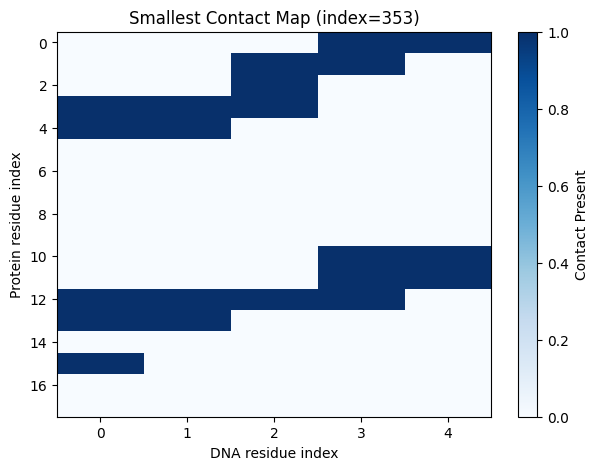

In [40]:
import matplotlib.pyplot as plt

# Find the entry with the smallest contact map (by product of shape)
sizes = dataset_residue_wise["contact_map"].map(lambda x: x.shape[0] * x.shape[1])
min_idx = sizes.idxmin()
smallest_contact_map = dataset_residue_wise.loc[min_idx, "contact_map"]

plt.figure(figsize=(7, 5))
plt.imshow(smallest_contact_map, cmap='Blues', aspect='auto')
plt.title(f'Smallest Contact Map (index={min_idx})')
plt.xlabel('DNA residue index')
plt.ylabel('Protein residue index')
plt.colorbar(label='Contact Present')
plt.show()



## Create Chain-wise dataset

In [7]:
import pandas as pd
import numpy as np

def extract_chain_pairs(row, dist_threshold=5.0):
    """
    Splits a DNAproDB entry into multiple (Prot_Chain, DNA_Strand, Label) examples.
    """
    dataset_entries = []
    pdb_id = row.get('structure_id', 'unknown')
    
    # 1. Get Interaction Data
    # Map of interacting pairs: {(Prot_ID, DNA_ID): min_dist}
    interaction_map = {}
    try:
        interactions = row['interfaces']['models'][0][0]['nucleotide-residue_interactions']
        for interaction in interactions:
            p_id = interaction['res_id'] # e.g. 'A.123.'
            n_id = interaction['nuc_id'] # e.g. 'P.10.'
            dist = interaction['min_distance']
            
            # We need to map residue IDs back to Chain IDs
            # Parse 'A.123.' -> Chain 'A'
            p_chain = p_id.split('.')[0]
            n_chain = n_id.split('.')[0]
            
            # Store the minimum distance found between these two chains
            key = (p_chain, n_chain)
            if key not in interaction_map or dist < interaction_map[key]:
                interaction_map[key] = dist
    except (KeyError, IndexError, TypeError):
        pass

    # 2. Iterate all Protein Chains
    if 'chains' in row['protein']:
        for p_chain_data in row['protein']['chains']:
            p_chain_id = p_chain_data['au_chain_id'] # e.g., 'A'
            p_seq = p_chain_data['sequence']
            
            # 3. Iterate all DNA Chains
            if 'chains' in row['dna']:
                for d_chain_data in row['dna']['chains']:
                    d_chain_id = d_chain_data['au_chain_id'] # e.g., 'P'
                    d_seq = d_chain_data['sequence']
                    
                    # 4. Determine Label
                    # Check if this specific pair (A, P) interacts
                    min_dist = interaction_map.get((p_chain_id, d_chain_id), 999.9)
                    label = 1 if min_dist <= dist_threshold else 0
                    
                    dataset_entries.append({
                        'pdb_id': pdb_id,
                        'prot_chain_id': p_chain_id,
                        'dna_chain_id': d_chain_id,
                        'prot_seq': p_seq,
                        'dna_seq': d_seq,
                        'label': label
                    })
                    
    return dataset_entries

# --- Execution ---
# df.apply() is tricky with lists, so we use a standard loop or flatmap
all_examples = []
for index, row in df.iterrows():
    pairs = extract_chain_pairs(row)
    all_examples.extend(pairs)

# Convert to clean DataFrame for ML
dataset_chain_wise = pd.DataFrame(all_examples)

print(f"Generated {len(dataset_chain_wise)} training examples from {len(df)} structures.")
print(dataset_chain_wise.head())

Generated 48800 training examples from 7528 structures.
  pdb_id prot_chain_id dna_chain_id  \
0   8wh4             A            T   
1   8wh4             B            T   
2   8wh4             C            T   
3   8wh4             D            T   
4   8wh4             E            T   

                                            prot_seq dna_seq  label  
0  GNKLFNIAQRILDTNSVLLTERGDHIVWINNSWKFNSEEPLITKLI...    CCCC      0  
1  GNKLFNIAQRILDTNSVLLTERGDHIVWINNSWKFNSEEPLITKLI...    CCCC      1  
2  GNKLFNIAQRILDTNSVLLTERGDHIVWINNSWKFNSEEPLITKLI...    CCCC      1  
3  GNKLFNIAQRILDTNSVLLTERGDHIVWINNSWKFNSEEPLITKLI...    CCCC      1  
4  GNKLFNIAQRILDTNSVLLTERGDHIVWINNSWKFNSEEPLITKLI...    CCCC      0  


In [8]:
dataset_chain_wise.to_parquet("/home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/dna_protein_chain_wise.parquet")

In [9]:
dataset_chain_wise["dna_seq"].map(len).value_counts()

dna_seq
145    2843
146    2814
147    2148
12     1940
16     1847
       ... 
106       8
58        7
87        6
84        6
74        2
Name: count, Length: 184, dtype: int64

In [10]:
display(dataset_chain_wise[dataset_chain_wise["prot_seq"].map(len) < 40]["label"].value_counts())
display(dataset_chain_wise[dataset_chain_wise["dna_seq"].map(len) > 20]["label"].value_counts())


label
0    598
1     60
Name: count, dtype: int64

label
1    18481
0     7208
Name: count, dtype: int64

### Quality control the data

In [15]:
min_prot_len = 40
max_prot_len = 1024 
min_dna_len = 6

dataset_chain_wise_cleaned = dataset_chain_wise[
    (dataset_chain_wise['prot_seq'].map(len) >= min_prot_len) & 
    (dataset_chain_wise['prot_seq'].map(len) <= max_prot_len) & 
    (dataset_chain_wise['dna_seq'].map(len) >= min_dna_len)
]


In [ ]:

output_fasta = DATA_DIR / "working" / "dnaprodb2" / "proteins_for_clustering.fasta"

with open(output_fasta, "w") as f:
    # Iterate over unique protein sequences to save time
    # (Multiple PDBs might share the exact same sequence)
    unique_prots = dataset_chain_wise_cleaned[['prot_seq']].drop_duplicates().reset_index()
    
    for idx, row in unique_prots.iterrows():
        # Format: >SequenceIndex
        #         SEQUENCE...
        f.write(f">{idx}\n{row['prot_seq']}\n")

print(f"Exported {len(unique_prots)} unique sequences to {output_fasta}")

Exported 8465 unique sequences to /home/zcorn/Projects/proteinDNA_data/working/dnaprodb2/proteins_for_clustering.fasta


In [19]:
# Parameters:
# --min-seq-id 0.3  -> 30% Sequence Identity (Standard homology cutoff)
# -c 0.8            -> 80% Coverage (Prevents a small fragment clustering with a full protein)
# --cov-mode 1      -> Coverage of the target sequence (Strict)

#! mmseqs easy-cluster proteins_for_clustering.fasta cluster_result tmp --min-seq-id 0.3 -c 0.8 --cov-mode 1

In [20]:
# 1. Load the MMseqs2 result
# Columns: [Cluster_Representative_ID, Member_Sequence_ID]
cluster_df = pd.read_csv(DATA_DIR / "working" / "dnaprodb2" / "cluster_result_cluster.tsv", sep='\t', names=["cluster_rep", "seq_id"])

# 2. Convert IDs back to integers (since we used >0, >1 in FASTA)
cluster_df['seq_id'] = cluster_df['seq_id'].astype(int)

# 3. Merge with your Unique Proteins DataFrame (from Step 2)
# Recall: 'unique_prots' had columns ['index', 'prot_seq'] where index matched the FASTA header
unique_prots = dataset_chain_wise_cleaned[['prot_seq']].drop_duplicates().reset_index(drop=True)
# Note: In Step 2 we used default iteration index. Let's align correctly:
unique_prots['seq_id'] = unique_prots.index

# Join to get the cluster ID for every unique sequence
merged_unique = pd.merge(unique_prots, cluster_df, on='seq_id')

# 4. Create a Map: Protein Sequence -> Cluster ID
prot_to_cluster_map = dict(zip(merged_unique['prot_seq'], merged_unique['cluster_rep']))

# 5. Apply to Main DataFrame
dataset_chain_wise_cleaned['cluster_id'] = dataset_chain_wise_cleaned['prot_seq'].map(prot_to_cluster_map)

# Verify
num_clusters = dataset_chain_wise_cleaned['cluster_id'].nunique()
print(f" Scientifically Valid Clustering Complete.")
print(f" Grouped {len(dataset_chain_wise_cleaned)} examples into {num_clusters} homology clusters.")


 Scientifically Valid Clustering Complete.
 Grouped 45533 examples into 1315 homology clusters.


/tmp/ipykernel_1809822/586567936.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_chain_wise_cleaned['cluster_id'] = dataset_chain_wise_cleaned['prot_seq'].map(prot_to_cluster_map)


In [22]:
dataset_chain_wise_cleaned

,pdb_id,prot_chain_id,dna_chain_id,prot_seq,dna_seq,label,cluster_id
6,3bq2,A,P,MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...,GAAGCCGGCGG,1,2249
7,3bq2,A,T,MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...,CCGCCCGGCTTC,1,2249
8,3exj,A,C,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,GAGCATGCTCA,1,8232
9,3exj,A,D,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,TTGAGCATGCTC,1,8232
10,3exj,A,C,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,GAGCATGCTCA,1,8232
...,...,...,...,...,...,...,...
48795,9y47,F,J,NIQGITKPAIRRLARRGGVKRISGLIYEETRGVLKVFLENVIRDAV...,TCGAGAATCCCGGTGCCGAGGCCGCTCAATTGGTCGTAGACAGCTC...,1,848
48796,9y47,G,I,ARAKAKTRSSRAGLQFPVGRVHRLLRKGNYAERVGAGAPVYLAAVL...,TCGGATGTATATATCTGACACGTGCCTGGAGACTAGGGAGTAATCC...,1,6391
48797,9y47,G,J,ARAKAKTRSSRAGLQFPVGRVHRLLRKGNYAERVGAGAPVYLAAVL...,TCGAGAATCCCGGTGCCGAGGCCGCTCAATTGGTCGTAGACAGCTC...,1,6391
48798,9y47,H,I,RSRKESYSVYVYKVLKQVHPDTGISSKAMGIMNSFVNDIFERIAGE...,TCGGATGTATATATCTGACACGTGCCTGGAGACTAGGGAGTAATCC...,1,2632


In [24]:
dataset_chain_wise_cleaned.to_parquet(DATA_DIR / "working" / "dnaprodb2" / "dna_protein_chain_wise_cleaned.parquet")

In [25]:
dataset_chain_wise_cleaned

,pdb_id,prot_chain_id,dna_chain_id,prot_seq,dna_seq,label,cluster_id
6,3bq2,A,P,MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...,GAAGCCGGCGG,1,2249
7,3bq2,A,T,MIVIFVDFDYFFAQVEEVLNPQYKGKPLVVCVYSGTSGAVATANYE...,CCGCCCGGCTTC,1,2249
8,3exj,A,C,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,GAGCATGCTCA,1,8232
9,3exj,A,D,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,TTGAGCATGCTC,1,8232
10,3exj,A,C,KTYQGNYGFHLGFLQSGTAKSVMCTYSPPLNKLFCQLAKTCPVQLW...,GAGCATGCTCA,1,8232
...,...,...,...,...,...,...,...
48795,9y47,F,J,NIQGITKPAIRRLARRGGVKRISGLIYEETRGVLKVFLENVIRDAV...,TCGAGAATCCCGGTGCCGAGGCCGCTCAATTGGTCGTAGACAGCTC...,1,848
48796,9y47,G,I,ARAKAKTRSSRAGLQFPVGRVHRLLRKGNYAERVGAGAPVYLAAVL...,TCGGATGTATATATCTGACACGTGCCTGGAGACTAGGGAGTAATCC...,1,6391
48797,9y47,G,J,ARAKAKTRSSRAGLQFPVGRVHRLLRKGNYAERVGAGAPVYLAAVL...,TCGAGAATCCCGGTGCCGAGGCCGCTCAATTGGTCGTAGACAGCTC...,1,6391
48798,9y47,H,I,RSRKESYSVYVYKVLKQVHPDTGISSKAMGIMNSFVNDIFERIAGE...,TCGGATGTATATATCTGACACGTGCCTGGAGACTAGGGAGTAATCC...,1,2632


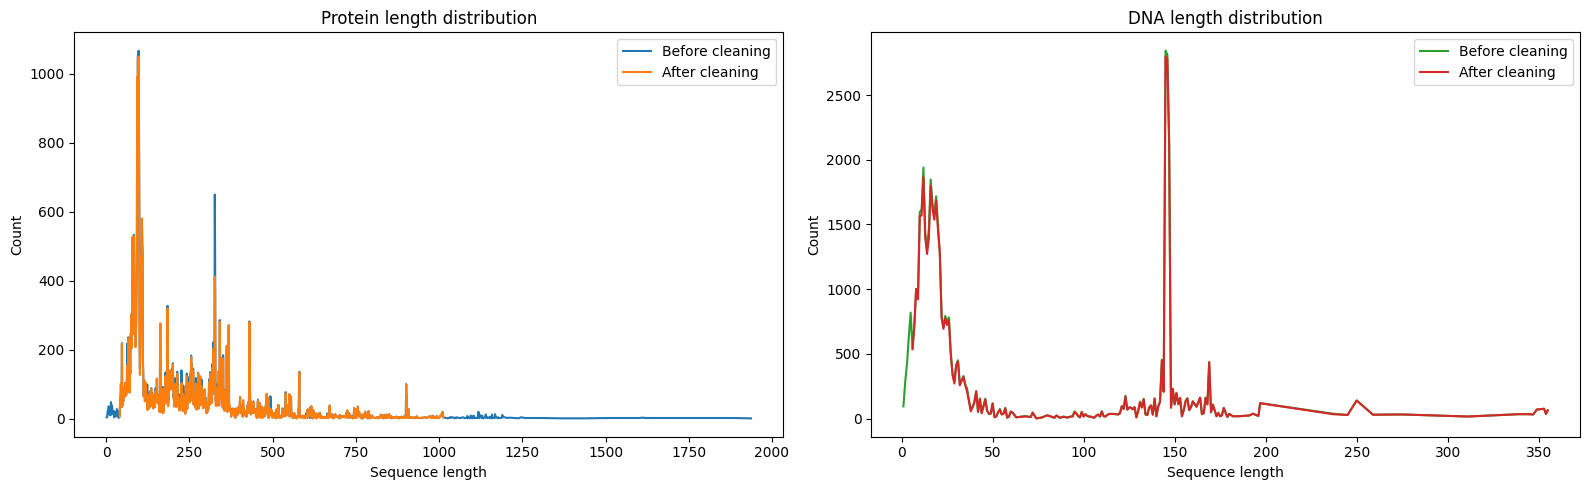

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)

# Protein sequence length distributions (before & after cleaning)
dataset_chain_wise["prot_seq"].map(len).value_counts().sort_index().plot(
    kind="line",
    ax=axes[0],
    color="tab:blue",
    label="Before cleaning"
)
dataset_chain_wise_cleaned["prot_seq"].map(len).value_counts().sort_index().plot(
    kind="line",
    ax=axes[0],
    color="tab:orange",
    label="After cleaning"
)
axes[0].set_title("Protein length distribution")
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("Count")
axes[0].legend()

# DNA sequence length distributions (before & after cleaning)
dataset_chain_wise["dna_seq"].map(len).value_counts().sort_index().plot(
    kind="line",
    ax=axes[1],
    color="tab:green",
    label="Before cleaning"
)
dataset_chain_wise_cleaned["dna_seq"].map(len).value_counts().sort_index().plot(
    kind="line",
    ax=axes[1],
    color="tab:red",
    label="After cleaning"
)
axes[1].set_title("DNA length distribution")
axes[1].set_xlabel("Sequence length")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

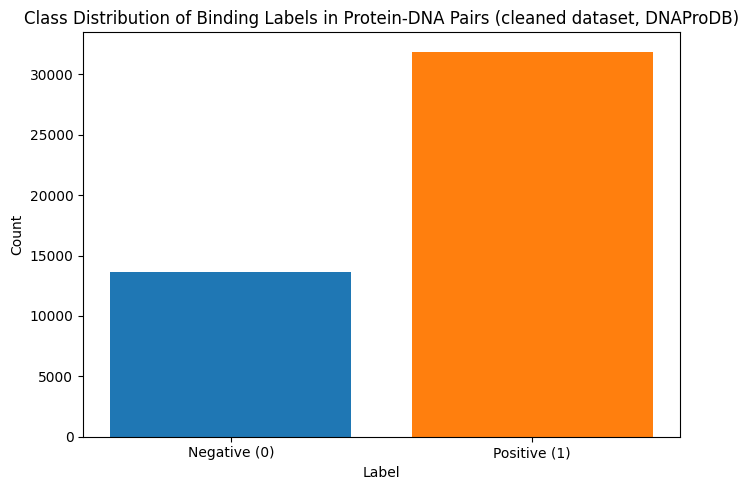

In [37]:
# Plot class distribution of binding labels (positive vs negative) as a standalone plot

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

# Positive vs Negative counts for DNA-protein pairs
label_counts = dataset_chain_wise_cleaned['label'].value_counts().sort_index()
ax.bar(['Negative (0)', 'Positive (1)'], label_counts.values, color=['tab:blue', 'tab:orange'])
ax.set_title('Class Distribution of Binding Labels in Protein-DNA Pairs (cleaned dataset, DNAProDB)')
ax.set_ylabel('Count')
ax.set_xlabel('Label')

plt.tight_layout()
plt.show()
